# 03 · Spatial Hierarchy & Graphs

[Index](./00_index.ipynb) · [← Previous](./02_geometry.ipynb) · [Next →](./04_classification.ipynb)

The IFC sample model `AC20-FZK-Haus.ifc` is provided as part of the KIT IFC example dataset, developed by the Institute for Automation and Applied Informatics (IAI) at Karlsruhe Institute of Technology (KIT). It is distributed for unrestricted use and commonly referenced in IFC tutorials, including IfcOpenShell documentation and sample workflows.

This notebook is standalone: it re-downloads and re-opens the model so it can run on its own in Colab, independent of the other notebooks in this portfolio.

In [1]:
!pip install -q ifcopenshell pandas numpy networkx pyvis matplotlib requests

In [2]:
import ifcopenshell
import ifcopenshell.util.element
import pandas as pd
import numpy as np
import requests
import json

import networkx as nx
from networkx.readwrite import json_graph
from pyvis.network import Network
from IPython.display import HTML, display

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [3]:
# Load the sample IFC model
import ifcopenshell
import requests

r = requests.get("https://www.ifcwiki.org/images/e/e3/AC20-FZK-Haus.ifc")
with open("model.ifc", "w") as f:
    f.write(r.text)

model = ifcopenshell.open("model.ifc")

print("Schema:", model.schema)
print("Walls:", len(model.by_type("IfcWall")))

Schema: IFC4
Walls: 13


In [4]:
# Shared categorical palette (fixed order — never reassign per-filter).
# Colorblind-validated: blue, orange, aqua, yellow, magenta, green, violet, red.
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
               "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SEQUENTIAL_BLUE = "#2a78d6"

## Spatial hierarchy
<a id="spatial-hierarchy"></a>

IFC is structured like:

```
Project
 └── Site
      └── Building
           └── Storey
                └── Elements
```

In [5]:
# Define Data Frame of storey → element relationships
rows = []

for rel in model.by_type("IfcRelContainedInSpatialStructure"):
    storey = rel.RelatingStructure

    for e in rel.RelatedElements:
        rows.append({
            "storey": storey.Name,
            "element": e.is_a(),
            "name": e.Name
        })

df_storey = pd.DataFrame(rows)
df_storey.head()

,storey,element,name
0,Erdgeschoss,IfcStair,Wendeltreppe
1,Erdgeschoss,IfcWallStandardCase,Wand-Int-ERDG-4
2,Erdgeschoss,IfcAnnotation,NaN
3,Erdgeschoss,IfcAnnotation,NaN
4,Erdgeschoss,IfcAnnotation,NaN


### Graphs

In addition to tabular and geometric analysis, IFC models can be interpreted as graphs, where building elements are represented as nodes and their relationships as edges. This lets us explicitly visualize and analyze structural, spatial, and semantic connections within the model rather than treating it as a collection of isolated objects.

This notebook builds four graphs, each covering one relationship family from the IFC schema:

| Graph | Relationship | IFC entity |
|---|---|---|
| Relations | storey → element, wall → opening → door/window, slab ↔ beam | `IfcRelContainedInSpatialStructure`, `IfcRelVoidsElement`, `IfcRelFillsElement` |
| Hierarchy | project → site → building → storey → elements | `IfcRelAggregates`, `IfcRelContainedInSpatialStructure` |
| Material | element → material | `IfcRelAssociatesMaterial` |
| Classification | element → classification reference | `IfcRelAssociatesClassification` |

In [6]:
# Shared helpers, used by every graph built below
def node_label(e):
    return f"{e.is_a()}: {e.Name or e.GlobalId[:8]}"


def add_ifc_node(G, e, group=None):
    G.add_node(
        e.GlobalId,
        label=node_label(e),
        group=group or e.is_a(),
        title=f"Type: {e.is_a()}\nName: {e.Name}\nGlobalId: {e.GlobalId}",
    )

#### 1. Relations graph — containment, openings, structural adjacency

In [7]:
# NOTE: earlier drafts of this notebook rebuilt `G` from scratch here after
# already building it once, silently discarding the wall→opening and
# opening→door/window edges. This is the single, correct build — one graph,
# every relationship family added to it, nothing overwritten.
G_relations = nx.DiGraph()

STRUCTURAL_CLASSES = {
    "IfcWall", "IfcWallStandardCase", "IfcSlab",
    "IfcDoor", "IfcWindow", "IfcColumn", "IfcBeam",
}

# 1a. Storey → structural elements
for rel in model.by_type("IfcRelContainedInSpatialStructure"):
    storey = rel.RelatingStructure
    if not storey.is_a("IfcBuildingStorey"):
        continue

    add_ifc_node(G_relations, storey, group="IfcBuildingStorey")

    for e in rel.RelatedElements:
        if e.is_a() in STRUCTURAL_CLASSES:
            add_ifc_node(G_relations, e)
            G_relations.add_edge(storey.GlobalId, e.GlobalId, relation="contains")

# 1b. Wall → opening
for rel in model.by_type("IfcRelVoidsElement"):
    wall, opening = rel.RelatingBuildingElement, rel.RelatedOpeningElement
    if wall.is_a() in {"IfcWall", "IfcWallStandardCase"}:
        add_ifc_node(G_relations, wall)
        add_ifc_node(G_relations, opening, group="IfcOpeningElement")
        G_relations.add_edge(wall.GlobalId, opening.GlobalId, relation="voids")

# 1c. Opening → door / window
for rel in model.by_type("IfcRelFillsElement"):
    opening, element = rel.RelatingOpeningElement, rel.RelatedBuildingElement
    if element.is_a() in {"IfcDoor", "IfcWindow"}:
        add_ifc_node(G_relations, opening, group="IfcOpeningElement")
        add_ifc_node(G_relations, element)
        G_relations.add_edge(opening.GlobalId, element.GlobalId, relation="fills")

# 1d. Slab ↔ beam (approximation: same-storey structural adjacency)
for rel in model.by_type("IfcRelContainedInSpatialStructure"):
    storey = rel.RelatingStructure
    if not storey.is_a("IfcBuildingStorey"):
        continue

    slabs = [e for e in rel.RelatedElements if e.is_a() == "IfcSlab"]
    beams = [e for e in rel.RelatedElements if e.is_a() == "IfcBeam"]

    for slab in slabs:
        add_ifc_node(G_relations, slab)
        for beam in beams:
            add_ifc_node(G_relations, beam)
            G_relations.add_edge(slab.GlobalId, beam.GlobalId, relation="same_storey_structural_relation")

print("Nodes:", G_relations.number_of_nodes())
print("Edges:", G_relations.number_of_edges())

Nodes: 55
Edges: 79


#### 2. Hierarchy graph — Project → Site → Building → Storey → Elements

In [8]:
G_hierarchy = nx.DiGraph()

SPATIAL_PARENTS = {"IfcProject", "IfcSite", "IfcBuilding", "IfcBuildingStorey"}

# 2a. Project → Site → Building → Storey, via decomposition
for rel in model.by_type("IfcRelAggregates"):
    parent = rel.RelatingObject
    if parent.is_a() not in SPATIAL_PARENTS:
        continue

    add_ifc_node(G_hierarchy, parent, group=parent.is_a())

    for child in rel.RelatedObjects:
        if child.is_a() in SPATIAL_PARENTS:
            add_ifc_node(G_hierarchy, child, group=child.is_a())
            G_hierarchy.add_edge(parent.GlobalId, child.GlobalId, relation="aggregates")

# 2b. Storey → Elements, via spatial containment
for rel in model.by_type("IfcRelContainedInSpatialStructure"):
    storey = rel.RelatingStructure
    if not storey.is_a("IfcBuildingStorey"):
        continue

    add_ifc_node(G_hierarchy, storey, group="IfcBuildingStorey")

    for e in rel.RelatedElements:
        add_ifc_node(G_hierarchy, e, group="Element")
        G_hierarchy.add_edge(storey.GlobalId, e.GlobalId, relation="contains")

print("Nodes:", G_hierarchy.number_of_nodes())
print("Edges:", G_hierarchy.number_of_edges())

Nodes: 101
Edges: 100


#### 3. Material graph — element → material

In [9]:
def material_name(mat):
    """Best-effort display name across IFC's several material entity shapes."""
    if mat is None:
        return None
    if mat.is_a("IfcMaterial"):
        return mat.Name
    if mat.is_a("IfcMaterialLayerSetUsage"):
        return material_name(mat.ForLayerSet)
    if mat.is_a("IfcMaterialLayerSet"):
        names = [l.Material.Name for l in mat.MaterialLayers if l.Material]
        return mat.LayerSetName or " + ".join(names) or None
    if mat.is_a("IfcMaterialList"):
        return " + ".join(m.Name for m in mat.Materials if m.Name)
    if mat.is_a("IfcMaterialConstituentSet"):
        names = [c.Material.Name for c in mat.MaterialConstituents if c.Material]
        return mat.Name or " + ".join(names) or None
    return getattr(mat, "Name", None) or mat.is_a()


G_material = nx.DiGraph()

for e in model.by_type("IfcBuildingElement"):
    try:
        mat = ifcopenshell.util.element.get_material(e)
    except Exception:
        mat = None

    name = material_name(mat)
    if not name:
        continue

    add_ifc_node(G_material, e)
    G_material.add_node(f"material:{name}", label=name, group="Material", title=f"Material: {name}")
    G_material.add_edge(e.GlobalId, f"material:{name}", relation="has_material")

print("Nodes:", G_material.number_of_nodes())
print("Edges:", G_material.number_of_edges())

Nodes: 85
Edges: 78


#### 4. Classification graph — element → classification reference

In [10]:
G_classification = nx.DiGraph()

class_rels = model.by_type("IfcRelAssociatesClassification")

for rel in class_rels:
    ref = rel.RelatingClassification
    ref_name = getattr(ref, "Name", None) or getattr(ref, "Identification", None) or ref.is_a()

    G_classification.add_node(
        f"class:{ref.GlobalId if hasattr(ref, 'GlobalId') else ref_name}",
        label=ref_name, group="Classification", title=f"Classification: {ref_name}",
    )

    for obj in rel.RelatedObjects:
        add_ifc_node(G_classification, obj)
        G_classification.add_edge(
            obj.GlobalId,
            f"class:{ref.GlobalId if hasattr(ref, 'GlobalId') else ref_name}",
            relation="classified_as",
        )

if not class_rels:
    print("No IfcRelAssociatesClassification relationships in this model — "
          "the AC20-FZK-Haus sample isn't classified against a system "
          "(e.g. Uniclass, OmniClass). G_classification is an empty graph; "
          "the code above still runs unchanged against a model that does "
          "carry classification data.")

print("Nodes:", G_classification.number_of_nodes())
print("Edges:", G_classification.number_of_edges())

Nodes: 8
Edges: 7


### Interactive visualization

In [11]:
# Display Interactive Graph (relations graph — the richest of the four)
net = Network(
    height="750px",
    width="100%",
    directed=True,
    notebook=True,
    cdn_resources="in_line"
)

net.from_nx(G_relations)
net.show_buttons(filter_=["physics"])

# Written explicitly as UTF-8 (rather than via net.show(), which opens the
# file with the platform default encoding) because IFC element names in
# this model contain non-ASCII characters — on Windows that default is
# cp1252, which raises UnicodeEncodeError partway through the write.
html = net.generate_html("ifc_graph.html", notebook=True)
with open("ifc_graph.html", "w", encoding="utf-8") as f:
    f.write(html)

display(HTML(html))

In [12]:
# Download Graph — Colab only; both files are already saved to disk above,
# so locally this just confirms their path instead of triggering a browser
# download.
data = json_graph.node_link_data(G_relations)
with open("ifc_graph.json", "w") as f:
    json.dump(data, f)

try:
    from google.colab import files
    files.download("ifc_graph.html")
    files.download("ifc_graph.json")
except ImportError:
    import os
    print("Not running in Colab — files saved locally instead:")
    print(" -", os.path.abspath("ifc_graph.html"))
    print(" -", os.path.abspath("ifc_graph.json"))

Not running in Colab — files saved locally instead:
 - C:\Users\ReDI\Downloads\Claude Fun\ifc_analysis_portfolio\ifc_graph.html
 - C:\Users\ReDI\Downloads\Claude Fun\ifc_analysis_portfolio\ifc_graph.json


### Graph analytics

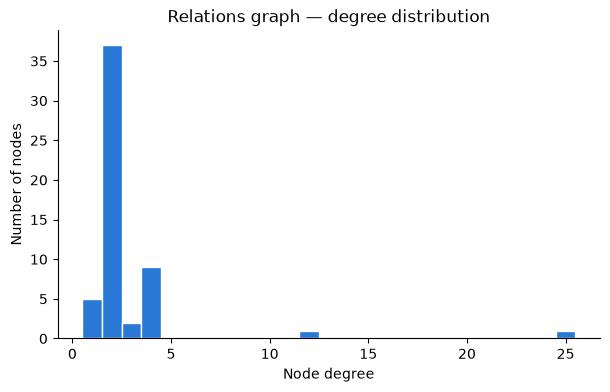

In [13]:
# Degree distribution of the relations graph
degrees = [d for _, d in G_relations.degree()]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(degrees, bins=range(1, max(degrees) + 2), color=SEQUENTIAL_BLUE,
        edgecolor="white", align="left")
ax.set_xlabel("Node degree")
ax.set_ylabel("Number of nodes")
ax.set_title("Relations graph — degree distribution")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

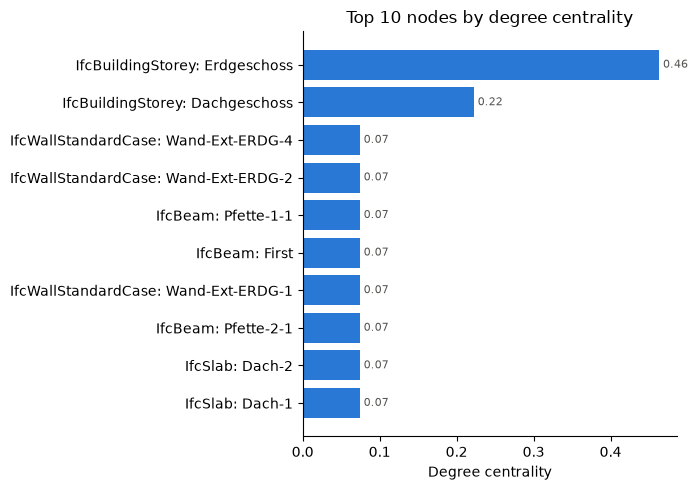

,node,label,degree_centrality,betweenness_centrality
0,2eyxpyOx95m90jmsXLOuR0,IfcBuildingStorey: Erdgeschoss,0.462963,0.000000
26,273g3wqLzDtfYIl7qqkgcO,IfcBuildingStorey: Dachgeschoss,0.222222,0.000000
14,16DNNqzfP2thtfaOflvsKA,IfcWallStandardCase: Wand-Ext-ERDG-4,0.074074,0.001048
21,1bzfVsJqn8De5PukCrqylz,IfcWallStandardCase: Wand-Ext-ERDG-2,0.074074,0.001048
28,3jZHeNcfvDMf9wG$wx9XqG,IfcBeam: Pfette-1-1,0.074074,0.000000
29,20bTaetQDApP5w8egFxj13,IfcBeam: First,0.074074,0.000000
10,3rPX_Juz59peXXY6wDJl18,IfcWallStandardCase: Wand-Ext-ERDG-1,0.074074,0.001048
27,0eaC0nL3XAOfFxRXK_2iAr,IfcBeam: Pfette-2-1,0.074074,0.000000
32,2IxUUNUVPB6Ob$eicCfP2N,IfcSlab: Dach-2,0.074074,0.000000
31,07Enbsqm9C7AQC9iyBwfSD,IfcSlab: Dach-1,0.074074,0.000000


In [14]:
# Centrality — which nodes hold the network together
degree_c = nx.degree_centrality(G_relations)
betweenness_c = nx.betweenness_centrality(G_relations)

df_centrality = pd.DataFrame({
    "node": list(degree_c.keys()),
    "label": [G_relations.nodes[n].get("label", n) for n in degree_c],
    "degree_centrality": list(degree_c.values()),
    "betweenness_centrality": [betweenness_c[n] for n in degree_c],
}).sort_values("degree_centrality", ascending=False)

top10 = df_centrality.head(10).iloc[::-1]  # reversed so the top row plots at the top

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top10["label"], top10["degree_centrality"], color=SEQUENTIAL_BLUE)
for y, v in enumerate(top10["degree_centrality"]):
    ax.text(v, y, f" {v:.2f}", va="center", fontsize=8, color="#52514e")
ax.set_xlabel("Degree centrality")
ax.set_title("Top 10 nodes by degree centrality")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

df_centrality.head(10)

In [15]:
# Connected components — is the model one connected network, or several islands?
components = list(nx.weakly_connected_components(G_relations))
sizes = sorted((len(c) for c in components), reverse=True)

print(f"{len(components)} weakly connected component(s)")
print("Largest component:", sizes[0], "nodes" if sizes else "n/a")

df_components = pd.DataFrame({"component_size": sizes})
df_components

2 weakly connected component(s)
Largest component: 40 nodes


,component_size
0,40
1,15


### Static hierarchical render

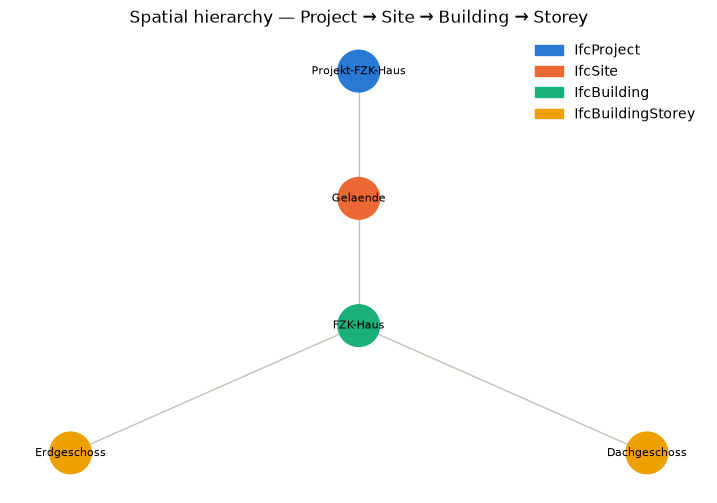

In [16]:
# Layered layout by BFS depth from the root(s) of G_hierarchy — a plain
# alternative to `G_relations`/PyVis that needs no Graphviz install and
# renders as a static image (useful for reports/PDF export).
def layered_layout(G):
    roots = [n for n, d in G.in_degree() if d == 0]
    depth = {}
    frontier = roots
    d = 0
    while frontier:
        for n in frontier:
            depth.setdefault(n, d)
        nxt = []
        for n in frontier:
            for succ in G.successors(n):
                if succ not in depth:
                    nxt.append(succ)
        frontier = nxt
        d += 1

    by_depth = {}
    for n, d in depth.items():
        by_depth.setdefault(d, []).append(n)

    pos = {}
    for d, nodes in by_depth.items():
        for i, n in enumerate(nodes):
            pos[n] = (i - len(nodes) / 2, -d)
    return pos


GROUP_COLORS = {
    "IfcProject": CATEGORICAL[0],
    "IfcSite": CATEGORICAL[1],
    "IfcBuilding": CATEGORICAL[2],
    "IfcBuildingStorey": CATEGORICAL[3],
}

# Elements dropped: with ~200 leaf nodes hanging off each storey, the tree
# read as noise rather than structure. This keeps just the spatial
# containers — Project -> Site -> Building -> Storey — one clean skeleton.
spatial_nodes = [n for n, d in G_hierarchy.nodes(data=True) if d.get("group") in GROUP_COLORS]
G_spatial = G_hierarchy.subgraph(spatial_nodes)

pos = layered_layout(G_spatial)
colors = [GROUP_COLORS.get(G_spatial.nodes[n].get("group"), "#898781") for n in G_spatial.nodes]
labels = {n: G_spatial.nodes[n].get("label", n).split(": ", 1)[-1] for n in G_spatial.nodes}

fig, ax = plt.subplots(figsize=(9, 6))
nx.draw(
    G_spatial, pos, ax=ax, node_color=colors, node_size=900,
    edge_color="#c3c2b7", width=1, arrows=False, with_labels=False,
)
nx.draw_networkx_labels(G_spatial, pos, labels=labels, font_size=8, ax=ax)
ax.set_title("Spatial hierarchy — Project → Site → Building → Storey")

legend_handles = [mpatches.Patch(color=c, label=g) for g, c in GROUP_COLORS.items()]
ax.legend(handles=legend_handles, loc="upper right", frameon=False)
plt.axis("off")
plt.show()